Part 1

In [1]:
import pickle
from torch.cuda._memory_viz import trace_plot

In [20]:
with open("memory-snapshots/fsdp2/rank0.pickle", "rb") as f:
    snapshot = pickle.load(f)

html_str = trace_plot(snapshot)

with open("fsdp2_memory_trace_big.html", "w") as f:
    f.write(html_str)


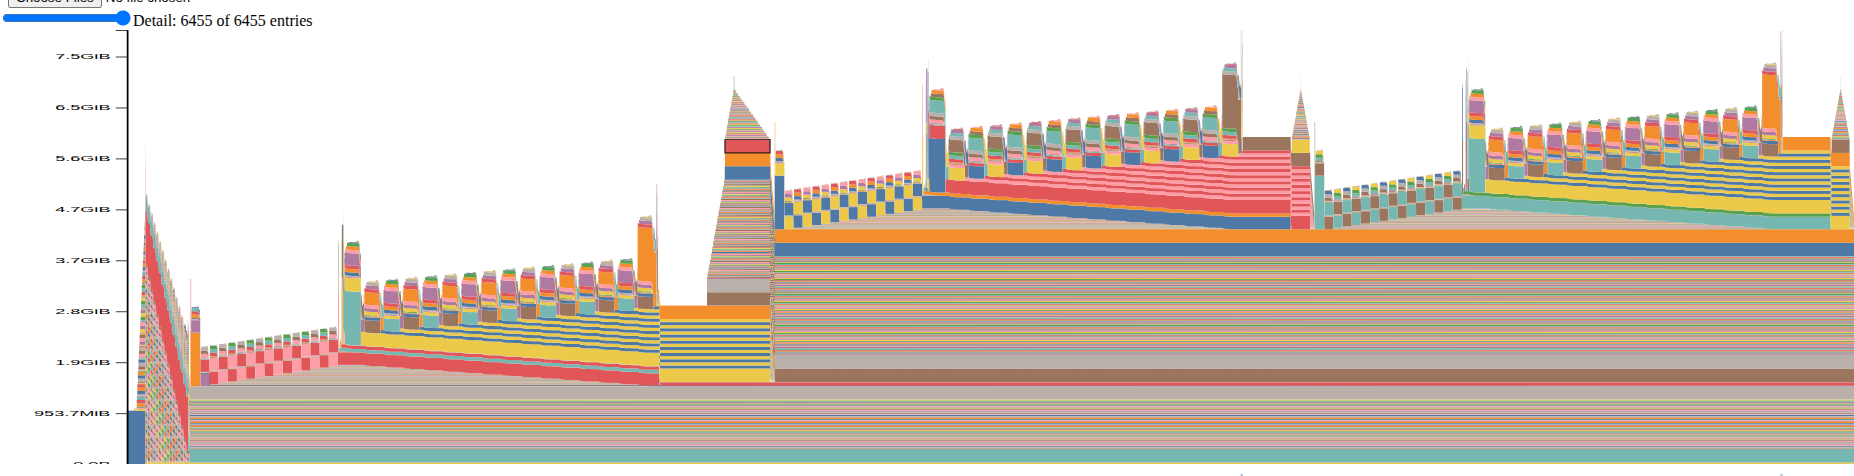

In [13]:
with open("memory-snapshots/effdl/rank0.pickle", "rb") as f:
    snapshot = pickle.load(f)

html_str = trace_plot(snapshot)

with open("effdl_memory_trace_big.html", "w") as f:
    f.write(html_str)


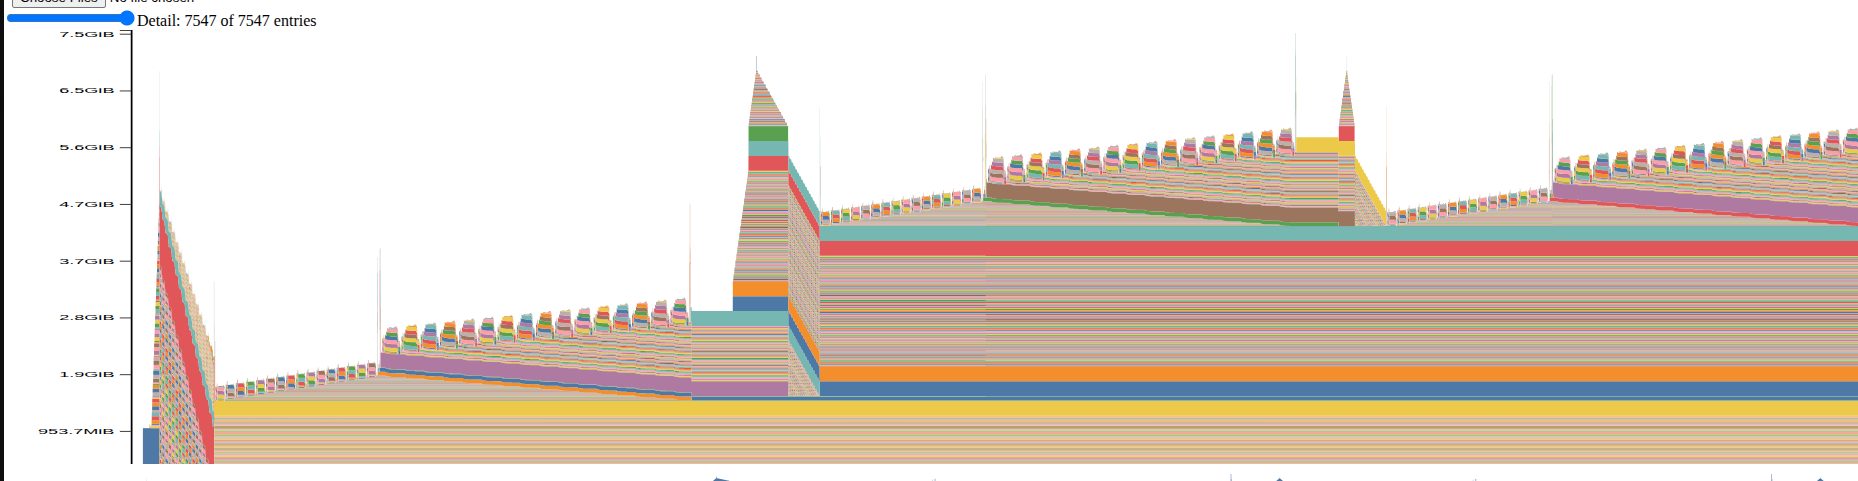
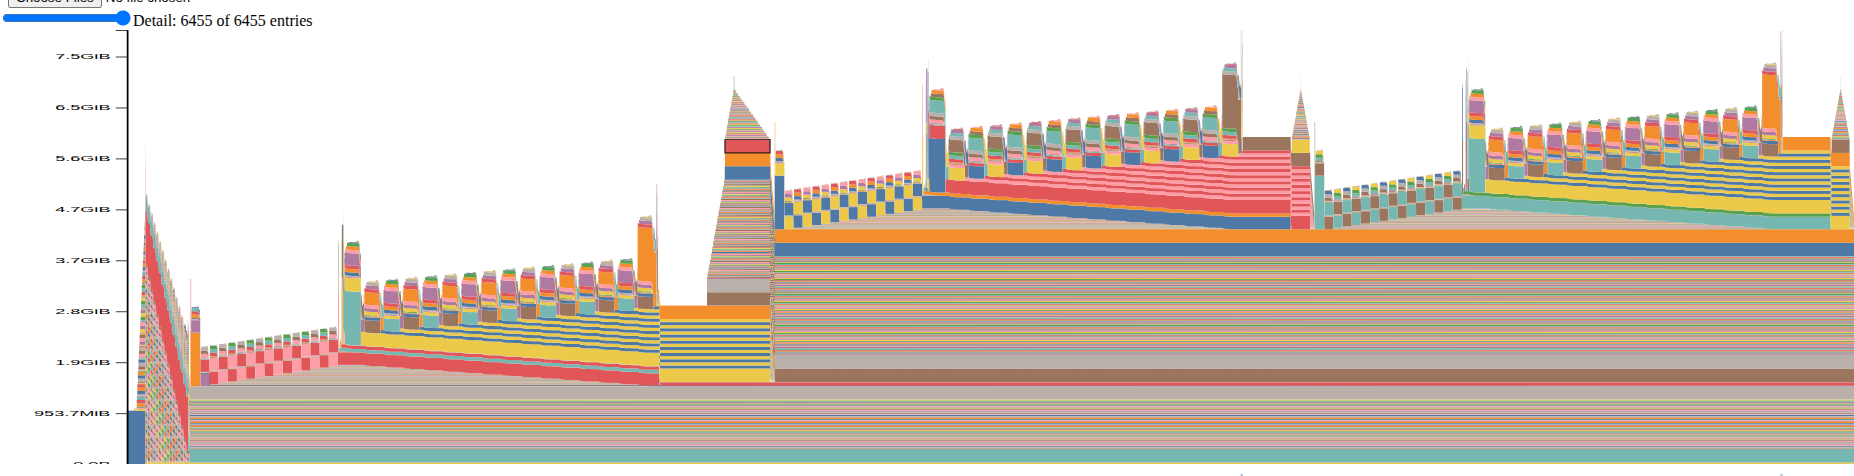

В чем была основная проблема: начиналпсь сборка первого слоя (то есть эмбэдингов), не дождавшись конца степа оптимайзера и удаления градиентов с прошлого батча и из-за этого пик по памяти был 8.5 Гб(на 1Гб больше чем у оригинального фсдп). Я сделал torch.cuda.synchronize() (в pre_forward) перед форвардом и пик пропал, но наверное можно как-то лучше дождаться очистки градиентов, но я пока оставил так, может пока буду делать вторую часть придумаю как сделать лучше. Скрин без torch.cuda.synchronize()

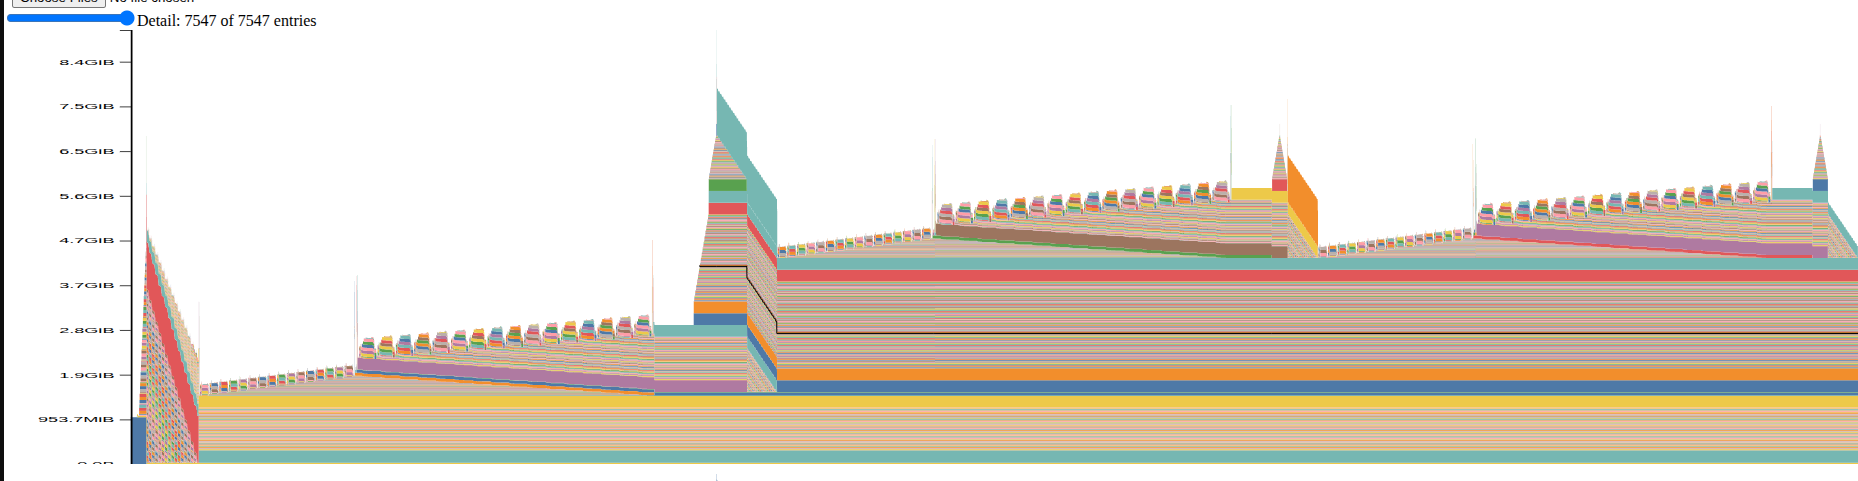

Part 2

without overlaping: all_gather - forward - all_gather

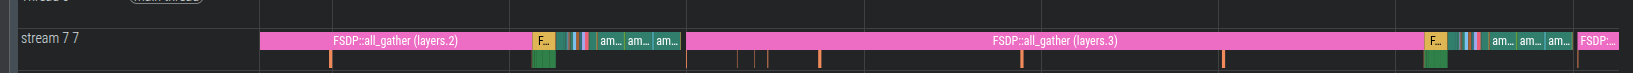

with overlaping: 

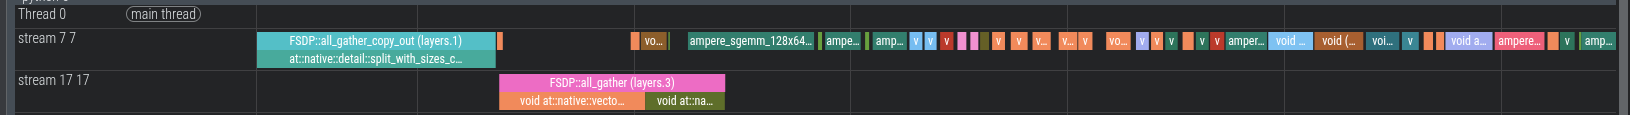

memory still fine

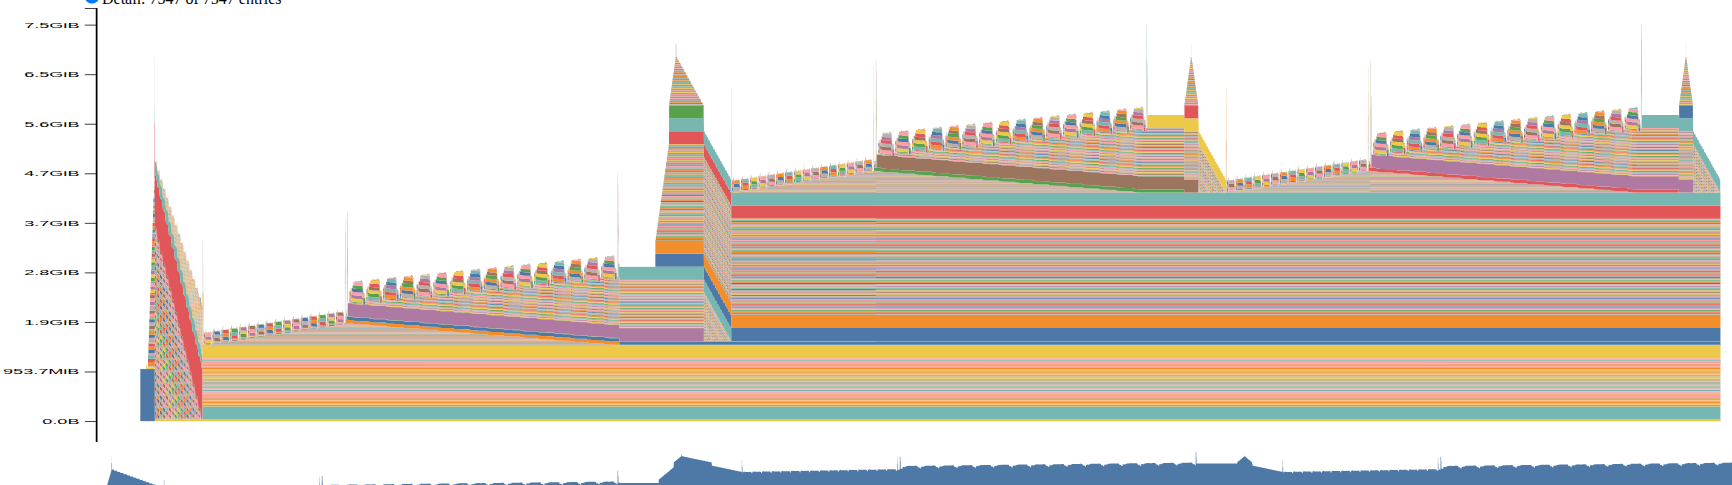

Part 3

Twice more memory for gradients on backward:

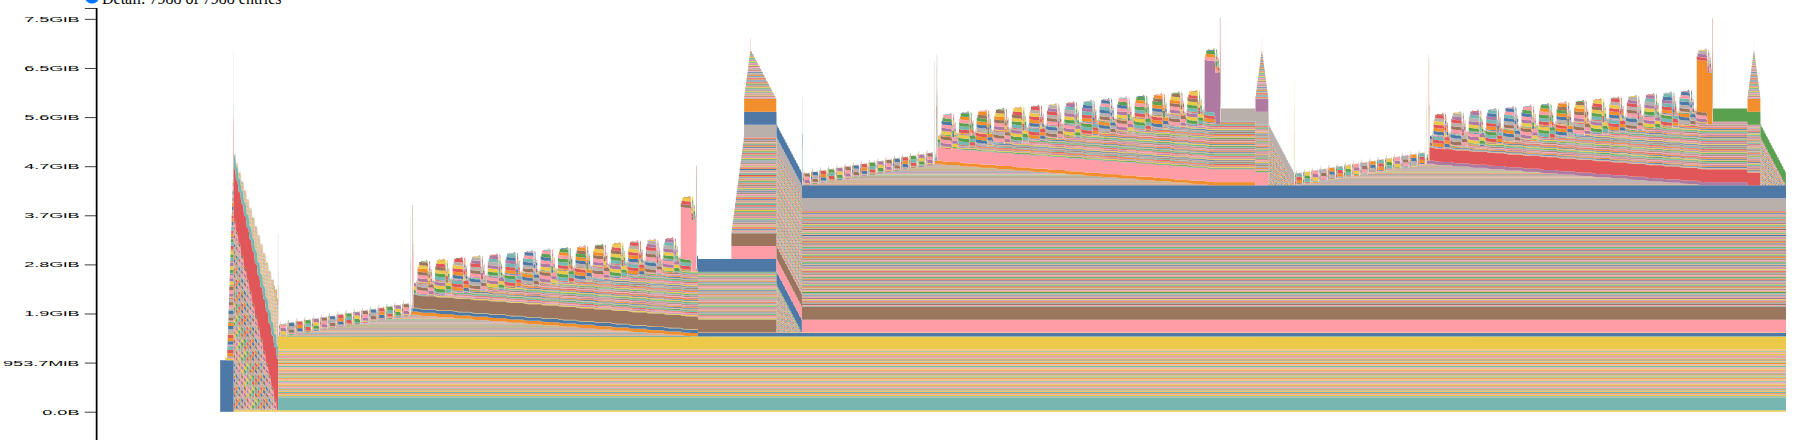

ovelap cuda kernal and reduce_scatter:

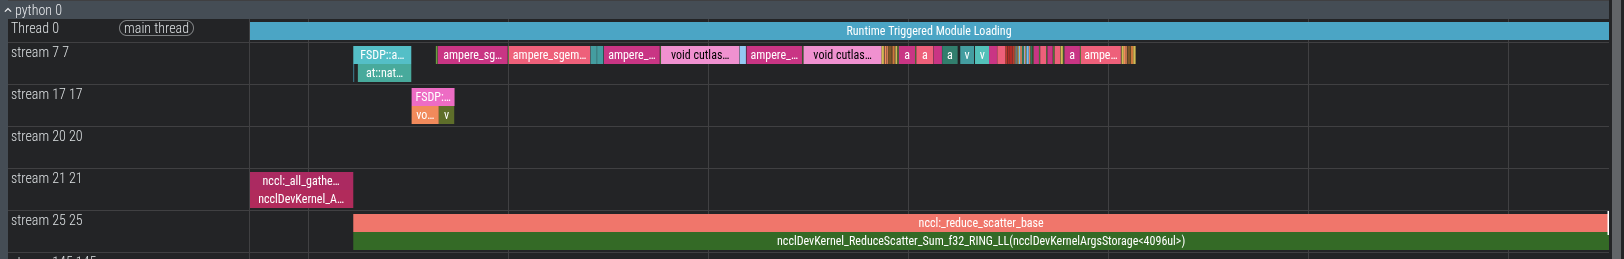